# Pharma Time Series & Regression Analysis
Analyzing pharmacy sales patterns over time with statistical regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading

In [2]:
# Load data
history_file = r'./DSLichSuGGMatHang6304_01302026163407.xlsx'
df_history = pd.read_excel(history_file, header=1)

# Filter for sales only
df_sales = df_history[df_history['NameNoteType'] == 'Xuất Bán'].copy()
df_sales['NoteDate'] = pd.to_datetime(df_sales['NoteDate'], format='%d/%m/%Y', errors='coerce')
df_sales = df_sales.dropna(subset=['NoteDate', 'Quantity'])

print(f'Total Sales Records: {len(df_sales)}')
print(f'Date Range: {df_sales["NoteDate"].min()} to {df_sales["NoteDate"].max()}')
df_sales.head()


# Load Cost Data (Drugs Master List)
drugs_file = r'./Drugs_6304_01302026162925.xlsx'
try:
    df_drugs = pd.read_excel(drugs_file, header=1)
    if 'Tên Thuốc' in df_drugs.columns and 'Giá Nhập' in df_drugs.columns:
        df_costs = df_drugs[['Tên Thuốc', 'Giá Nhập']].copy()
        df_costs.columns = ['NameDrug', 'BuyPrice']
        df_costs['BuyPrice'] = pd.to_numeric(df_costs['BuyPrice'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
        df_costs = df_costs.drop_duplicates(subset=['NameDrug'])
        
        # Merge into df_sales
        df_sales = df_sales.merge(df_costs, on='NameDrug', how='left')
        df_sales['BuyPrice'] = df_sales['BuyPrice'].fillna(0)
        print(f"Merged BuyPrice into df_sales. Matches: {len(df_sales[df_sales['BuyPrice']>0])} records.")
    else:
        print("Warning: Cost columns not found.")
except Exception as e:
    print(f"Warning: Could not load cost data: {e}")


Total Sales Records: 86052
Date Range: 2025-01-30 00:00:00 to 2026-01-30 00:00:00


## 2. Time Feature Engineering

In [3]:
import pandas as pd
import numpy as np

# 1. Ensure the column is datetime (Critical step)
df_sales['NoteDate'] = pd.to_datetime(df_sales['NoteDate'])

# 2. Extract basic time features
df_sales['Weekday'] = df_sales['NoteDate'].dt.day_name()
df_sales['Month'] = df_sales['NoteDate'].dt.month
df_sales['DayOfMonth'] = df_sales['NoteDate'].dt.day
df_sales['Year'] = df_sales['NoteDate'].dt.year

# 3. Vectorized Season Mapping (100x faster than .apply)
# We use np.select to handle conditional logic on the entire column at once
conditions = [
    df_sales['Month'].isin([3, 4, 5]),
    df_sales['Month'].isin([6, 7, 8]),
    df_sales['Month'].isin([9, 10, 11])
]
choices = ['Spring', 'Summer', 'Autumn']

# If none of the above are true, it defaults to 'Winter'
df_sales['Season'] = np.select(conditions, choices, default='Winter')

# 4. Display results
print(df_sales[['NoteDate', 'Weekday', 'Month', 'Season']].head(10))

    NoteDate Weekday  Month  Season
0 2026-01-30  Friday      1  Winter
1 2026-01-30  Friday      1  Winter
2 2026-01-30  Friday      1  Winter
3 2026-01-30  Friday      1  Winter
4 2026-01-30  Friday      1  Winter
5 2026-01-30  Friday      1  Winter
6 2026-01-30  Friday      1  Winter
7 2026-01-30  Friday      1  Winter
8 2026-01-30  Friday      1  Winter
9 2026-01-30  Friday      1  Winter


## 3. Daily Sales Aggregation

In [4]:
daily_sales = df_sales.groupby(df_sales['NoteDate'].dt.date)['Quantity'].sum().reset_index()
daily_sales.columns = ['Date', 'TotalQuantity']
daily_sales['DayNumber'] = range(1, len(daily_sales) + 1)

print(f'Number of days: {len(daily_sales)}')
print(f'Average daily sales: {daily_sales["TotalQuantity"].mean():,.0f}')
print(f'Std deviation: {daily_sales["TotalQuantity"].std():,.0f}')
daily_sales.head()

Number of days: 366
Average daily sales: 3,183
Std deviation: 6,012


,Date,TotalQuantity,DayNumber
0,2025-01-30,302.0,1
1,2025-01-31,6855.0,2
2,2025-02-01,229.0,3
3,2025-02-02,3246.0,4
4,2025-02-03,2050.0,5


## 4. Weekly Sales Distribution

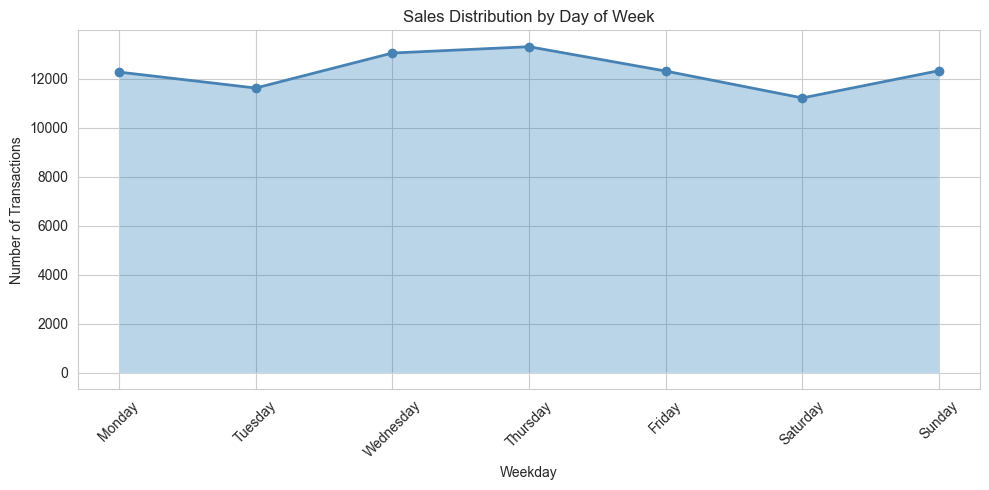

Busiest Day: Thursday with 13,299 transactions


In [5]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_counts = df_sales['Weekday'].value_counts().reindex(days_order)

plt.figure(figsize=(10, 5))
plt.plot(weekly_counts.index, weekly_counts.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(weekly_counts.index, weekly_counts.values, alpha=0.3)
plt.title('Sales Distribution by Day of Week')
plt.xlabel('Weekday')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f'Busiest Day: {weekly_counts.idxmax()} with {weekly_counts.max():,} transactions')

## 5. Monthly Sales Distribution

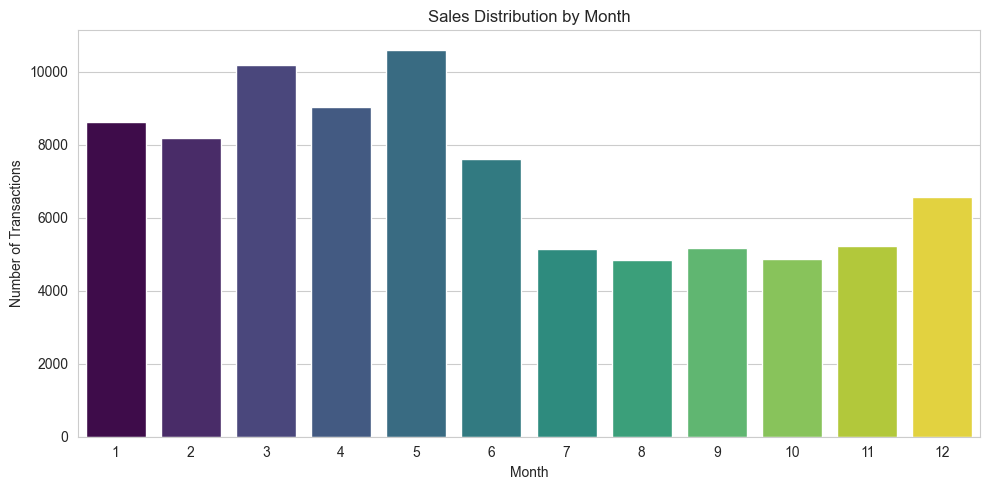

In [6]:
monthly_counts = df_sales['Month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_counts.index, y=monthly_counts.values, hue=monthly_counts.index, palette='viridis', legend=False)
plt.title('Sales Distribution by Month')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## 6. Seasonal Sales Analysis

In [7]:
import pandas as pd
import numpy as np

def get_top_items_optimized(df, n=30):
    # 0. Safety Check & Data Cleaning
    df_clean = df.copy()
    
    # Check for Season column
    if 'Season' not in df_clean.columns:
        print("⚠️ Warning: 'Season' column missing. Please run the 'Feature Engineering' cell first.")
        # Emergency fallback (assuming Month exists, if not, simplified)
        if 'Month' in df_clean.columns:
             df_clean['Season'] = np.select(
                [df_clean['Month'].isin([3,4,5]), df_clean['Month'].isin([6,7,8]), df_clean['Month'].isin([9,10,11])],
                ['Spring', 'Summer', 'Autumn'], default='Winter'
             )
        else:
             print("❌ Error: 'Month' column also missing. Cannot determine Season.")
             return

    # Check for BuyPrice column (Critical for ROI)
    if 'BuyPrice' not in df_clean.columns:
        print("⚠️ Warning: 'BuyPrice' column missing!")
        print("👉 SOLUTION: Please RE-RUN the 'Data Loading' cell (Cell 2) to load cost data.")
        df_clean['BuyPrice'] = 0.0 # Fill with 0 to prevent crash
    
    # Ensure numeric types for aggregation
    for col in ['Quantity', 'Price', 'BuyPrice']:
        if col in df_clean.columns:
            if df_clean[col].dtype == 'object':
                df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(',', ''), errors='coerce')
            else:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 1. Aggregation: Group by Season AND Drug in one shot
    summary = df_clean.groupby(['Season', 'NameDrug']).agg({
        'Quantity': 'sum',
        'Price': 'mean', 
        'BuyPrice': 'mean'
    }).reset_index()

    # 2. Vectorized ROI Calculation
    summary['ROI'] = np.where(
        summary['BuyPrice'] > 0, 
        (summary['Price'] - summary['BuyPrice']) / summary['BuyPrice'], 
        0.0
    )

    # 3. Sort and Filter Top N
    season_order = pd.CategoricalDtype(
        categories=['Spring', 'Summer', 'Autumn', 'Winter'], 
        ordered=True
    )
    summary['Season'] = summary['Season'].astype(season_order)
    
    top_items = summary.sort_values(['Season', 'Quantity'], ascending=[True, False])
    top_items = top_items.groupby('Season', observed=True).head(n)

    # 4. Display Logic
    for season in ['Spring', 'Summer', 'Autumn', 'Winter']:
        print(f'\n{"="*40}')
        print(f'🌿 Top Products in {season}')
        print("="*40)
        
        season_data = top_items[top_items['Season'] == season]
        
        for i, row in enumerate(season_data.itertuples(), 1):
            print(f'  {i}. {row.NameDrug}: {row.Quantity:,.0f} units (ROI: {row.ROI:.1%})')

get_top_items_optimized(df_sales)

⚠️ Warning: 'BuyPrice' column missing!
👉 SOLUTION: Please RE-RUN the 'Data Loading' cell (Cell 2) to load cost data.

🌿 Top Products in Spring
  1. khẩu trang hải long rẻ: 9,693 units (ROI: 0.0%)
  2. khẩu trang 5d hải long: 7,720 units (ROI: 0.0%)
  3. Alpha Choay: 7,595 units (ROI: 0.0%)
  4. Metilone-4: 6,550 units (ROI: 0.0%)
  5. Cavinton forte: 5,610 units (ROI: 0.0%)
  6. grarizine: 4,607 units (ROI: 0.0%)
  7. alphachymostrypsine phong phú: 4,226 units (ROI: 0.0%)
  8. Ketosteril 600mg: 3,297 units (ROI: 0.0%)
  9. kacerin: 3,288 units (ROI: 0.0%)
  10. cadimusol viên: 3,234 units (ROI: 0.0%)
  11. tanganil viên: 3,060 units (ROI: 0.0%)
  12. Zinc 15 meyer: 3,029 units (ROI: 0.0%)
  13. Neo-Godian: 2,989 units (ROI: 0.0%)
  14. probiotic 10ml: 2,816 units (ROI: 0.0%)
  15. bropase: 2,650 units (ROI: 0.0%)
  16. liver platinum viên: 2,640 units (ROI: 0.0%)
  17. avesimic *: 2,310 units (ROI: 0.0%)
  18. Crestor 10mg: 2,299 units (ROI: 0.0%)
  19. flunarizine 5mg sao kim: 2,240 u

---
## 7. Linear Regression - Sales Trend

In [8]:
X = daily_sales[['DayNumber']].values
y = daily_sales['TotalQuantity'].values

linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

print('📈 LINEAR REGRESSION RESULTS')
print('='*50)
print(f'Slope (Daily Trend): {linear_model.coef_[0]:.2f} units/day')
print(f'Intercept: {linear_model.intercept_:.2f}')
print(f'R² Score: {r2_score(y, y_pred_linear):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y, y_pred_linear)):.2f}')

if linear_model.coef_[0] > 0:
    print('\n✅ Trend: INCREASING sales over the period')
else:
    print('\n⚠️ Trend: DECREASING sales over the period')

📈 LINEAR REGRESSION RESULTS
Slope (Daily Trend): 5.10 units/day
Intercept: 2246.93
R² Score: 0.0081
RMSE: 5979.77

✅ Trend: INCREASING sales over the period


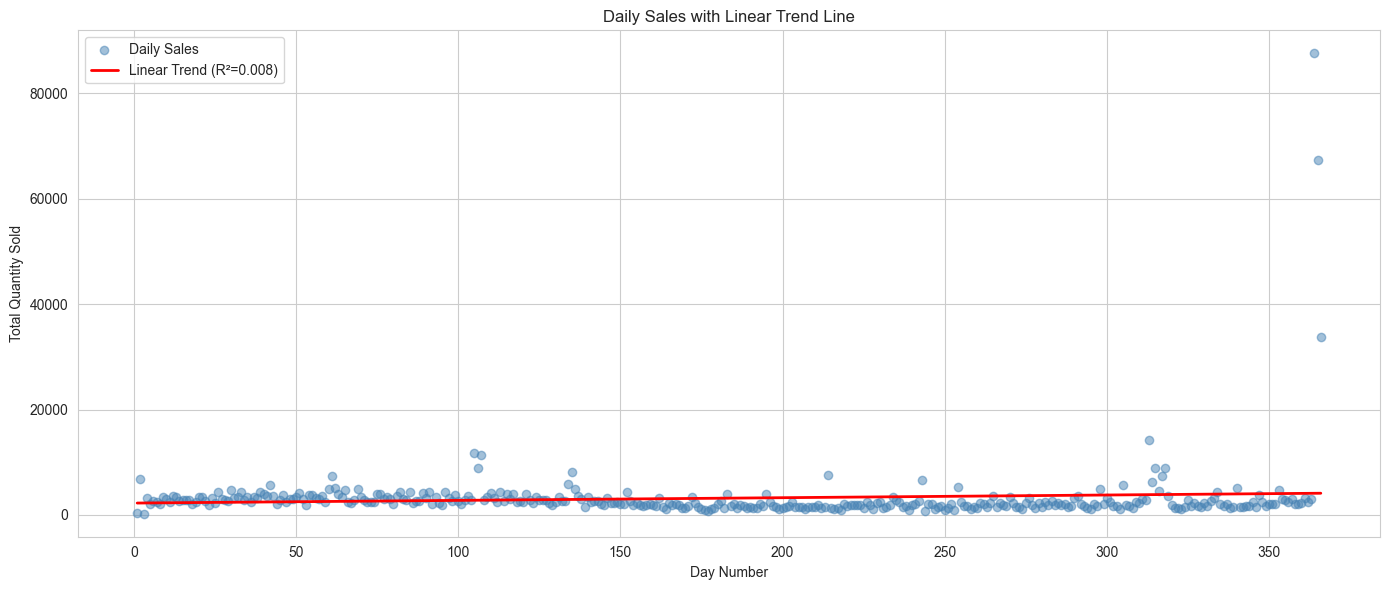

In [9]:
# Visualization
plt.figure(figsize=(14, 6))
plt.scatter(daily_sales['DayNumber'], daily_sales['TotalQuantity'], alpha=0.5, label='Daily Sales', color='steelblue')
plt.plot(daily_sales['DayNumber'], y_pred_linear, color='red', linewidth=2, label=f'Linear Trend (R²={r2_score(y, y_pred_linear):.3f})')
plt.xlabel('Day Number')
plt.ylabel('Total Quantity Sold')
plt.title('Daily Sales with Linear Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Polynomial Regression Comparison

In [10]:
print('📊 POLYNOMIAL REGRESSION COMPARISON')
print('='*50)

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)
    y_pred_poly = poly_model.predict(X_poly)
    r2 = r2_score(y, y_pred_poly)
    rmse = np.sqrt(mean_squared_error(y, y_pred_poly))
    print(f'Degree {degree}: R² = {r2:.4f}, RMSE = {rmse:.2f}')

📊 POLYNOMIAL REGRESSION COMPARISON
Degree 2: R² = 0.0559, RMSE = 5833.69
Degree 3: R² = 0.1207, RMSE = 5630.01


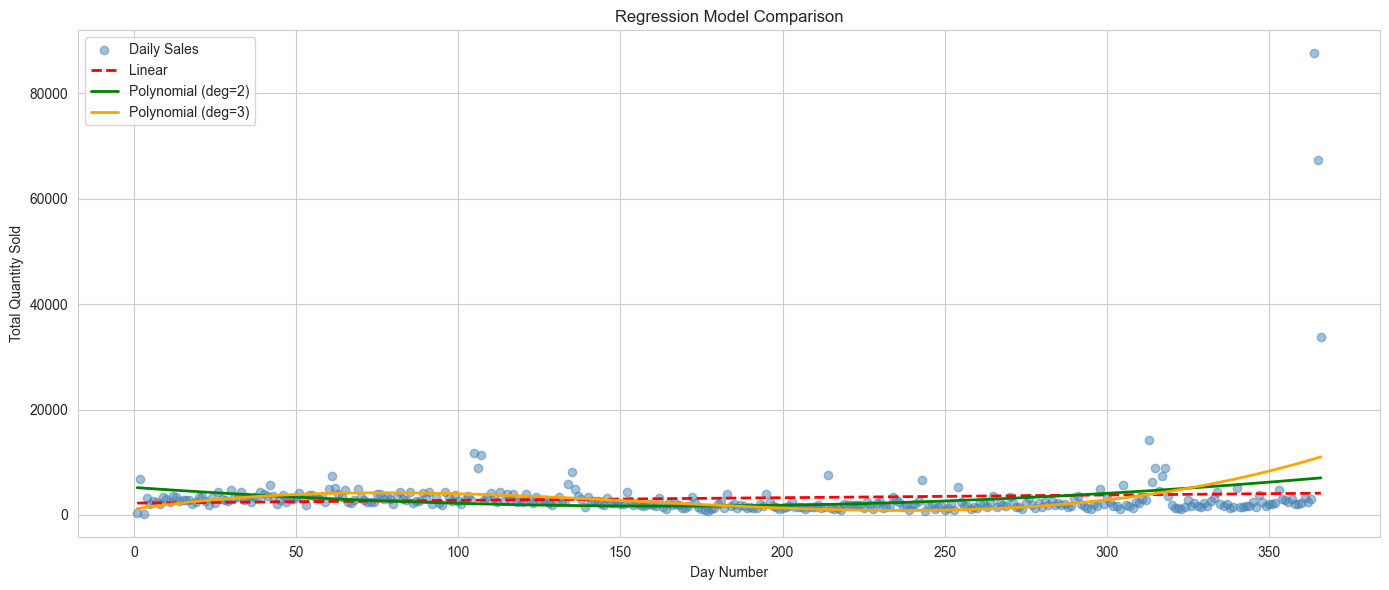

In [11]:
# Polynomial Visualization
plt.figure(figsize=(14, 6))
plt.scatter(daily_sales['DayNumber'], daily_sales['TotalQuantity'], alpha=0.5, label='Daily Sales', color='steelblue')
plt.plot(daily_sales['DayNumber'], y_pred_linear, color='red', linewidth=2, label='Linear', linestyle='--')

for deg, color in [(2, 'green'), (3, 'orange')]:
    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    plt.plot(daily_sales['DayNumber'], y_pred, color=color, linewidth=2, label=f'Polynomial (deg={deg})')

plt.xlabel('Day Number')
plt.ylabel('Total Quantity Sold')
plt.title('Regression Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Weekly Trend Regression

In [12]:
daily_sales['Week'] = (daily_sales['DayNumber'] - 1) // 7 + 1
weekly_agg = daily_sales.groupby('Week')['TotalQuantity'].sum().reset_index()

X_week = weekly_agg[['Week']].values
y_week = weekly_agg['TotalQuantity'].values

week_model = LinearRegression().fit(X_week, y_week)
y_week_pred = week_model.predict(X_week)

print('📅 WEEKLY TREND ANALYSIS')
print('='*50)
print(f'Weekly Trend: {week_model.coef_[0]:.2f} units/week')
print(f'R² Score: {r2_score(y_week, y_week_pred):.4f}')

📅 WEEKLY TREND ANALYSIS
Weekly Trend: 206.42 units/week
R² Score: 0.0342


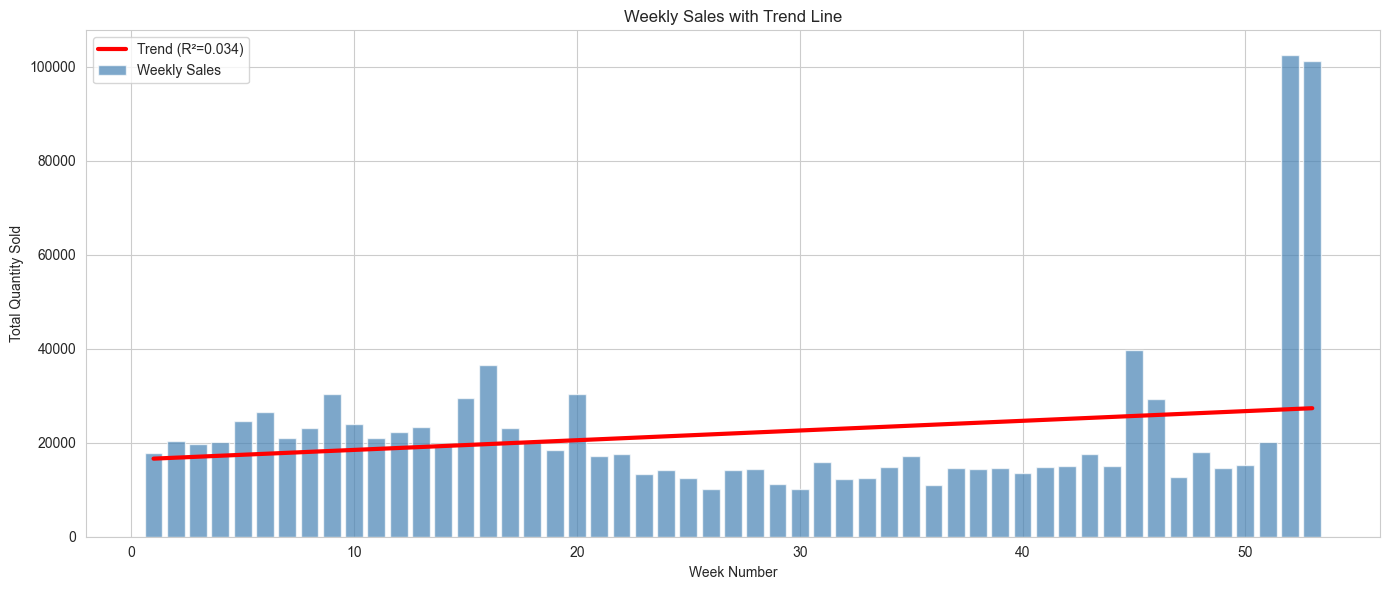

In [13]:
plt.figure(figsize=(14, 6))
plt.bar(weekly_agg['Week'], weekly_agg['TotalQuantity'], alpha=0.7, label='Weekly Sales', color='steelblue')
plt.plot(weekly_agg['Week'], y_week_pred, color='red', linewidth=3, label=f'Trend (R²={r2_score(y_week, y_week_pred):.3f})')
plt.xlabel('Week Number')
plt.ylabel('Total Quantity Sold')
plt.title('Weekly Sales with Trend Line')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Monthly Trend Regression

In [14]:
monthly_data = df_sales.groupby(df_sales['NoteDate'].dt.to_period('M'))['Quantity'].sum().reset_index()
monthly_data.columns = ['Month', 'TotalQuantity']
monthly_data['MonthNum'] = range(1, len(monthly_data) + 1)

X_month = monthly_data[['MonthNum']].values
y_month = monthly_data['TotalQuantity'].values

month_model = LinearRegression().fit(X_month, y_month)
y_month_pred = month_model.predict(X_month)

print('📆 MONTHLY TREND ANALYSIS')
print('='*50)
print(f'Monthly Trend: {month_model.coef_[0]:.2f} units/month')
print(f'R² Score: {r2_score(y_month, y_month_pred):.4f}')

📆 MONTHLY TREND ANALYSIS
Monthly Trend: 6462.29 units/month
R² Score: 0.1914


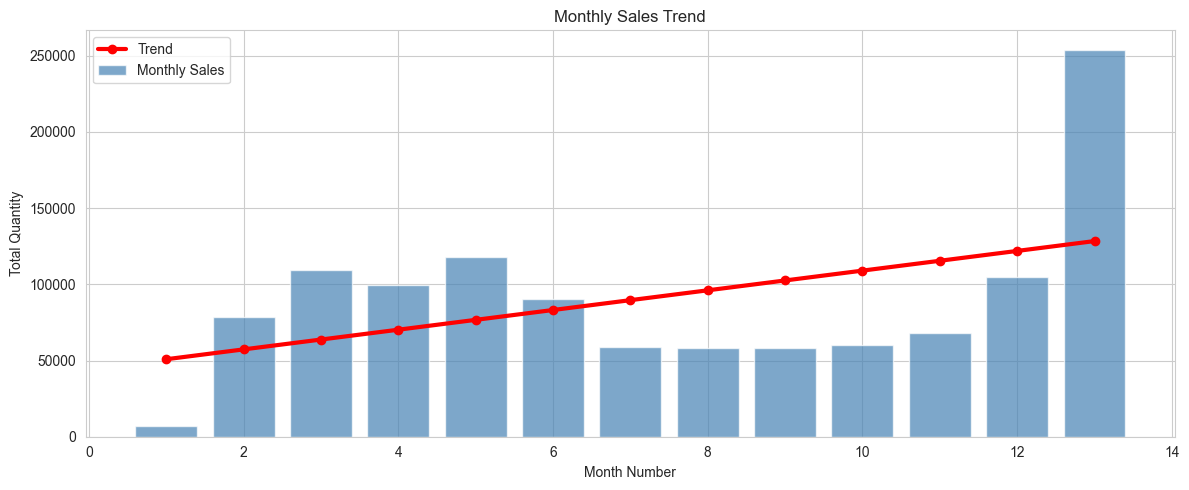

In [15]:
plt.figure(figsize=(12, 5))
plt.bar(monthly_data['MonthNum'], monthly_data['TotalQuantity'], alpha=0.7, color='steelblue', label='Monthly Sales')
plt.plot(monthly_data['MonthNum'], y_month_pred, color='red', linewidth=3, marker='o', label='Trend')
plt.xlabel('Month Number')
plt.ylabel('Total Quantity')
plt.title('Monthly Sales Trend')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Summary

In [16]:
print('📋 REGRESSION ANALYSIS SUMMARY')
print('='*60)
print(f'\n1. Daily Linear Trend: {linear_model.coef_[0]:.2f} units/day')
print(f'   - R² Score: {r2_score(y, y_pred_linear):.4f}')
print(f'\n2. Weekly Trend: {week_model.coef_[0]:.2f} units/week')
print(f'   - R² Score: {r2_score(y_week, y_week_pred):.4f}')
print(f'\n3. Monthly Trend: {month_model.coef_[0]:.2f} units/month')
print(f'   - R² Score: {r2_score(y_month, y_month_pred):.4f}')
print('\n' + '='*60)
if linear_model.coef_[0] > 0:
    print('📈 Overall: Sales are GROWING over time')
else:
    print('📉 Overall: Sales are DECLINING over time')
print('='*60)

📋 REGRESSION ANALYSIS SUMMARY

1. Daily Linear Trend: 5.10 units/day
   - R² Score: 0.0081

2. Weekly Trend: 206.42 units/week
   - R² Score: 0.0342

3. Monthly Trend: 6462.29 units/month
   - R² Score: 0.1914

📈 Overall: Sales are GROWING over time


## 3. Product Return & Time Decay Analysis
Analyzing profitability (Flat Return & ROI) and the impact of expiry dates (Time Decay) on sales.

In [17]:
# Load Cost Data (Drugs Master List)
drugs_file = r'./Drugs_6304_01302026162925.xlsx'
try:
    # Skip the first row which usually contains English headers based on inspection
    df_drugs = pd.read_excel(drugs_file)
    
    # Basic cleaning
    # Looking for 'Tên Thuốc' (Name) and 'Giá Nhập' (Buy Price)
    # Based on inspection, columns might be named 'Tên Thuốc' and 'Giá Nhập'
    print("Drugs File Columns:", df_drugs.columns.tolist())
    
    # Standardize column names if necessary
    if 'Tên Thuốc' in df_drugs.columns and 'Giá Nhập' in df_drugs.columns:
        df_costs = df_drugs[['Tên Thuốc', 'Giá Nhập']].copy()
        df_costs.columns = ['NameDrug', 'BuyPrice']
        df_costs['BuyPrice'] = pd.to_numeric(df_costs['BuyPrice'].astype(str).str.replace(',', ''), errors='coerce').fillna(0)
        # Remove duplicates, keeping the first (or max price?)
        df_costs = df_costs.drop_duplicates(subset=['NameDrug'])
        print(f"Loaded Cost Data for {len(df_costs)} unique drugs.")
    else:
        print("CRITICAL ERROR: Required columns 'Tên Thuốc' or 'Giá Nhập' not found in Drugs file.")
        
except Exception as e:
    print(f"Error loading Drugs file: {e}")

Drugs File Columns: ['Mã Thuốc', 'Nhóm Thuốc', 'Tên Thuốc', 'Thông Tin', 'Vị trí tủ, kho', 'Giá Nhập', 'Giá Bán Lẻ', 'Vat(%)', 'Trạng thái tích điểm\n(0 -bỏ tích, 1-tích)', 'Tích điểm(%)', 'Trạng thái chiết khấu theo lợi nhuận\n(0 -bỏ tích, 1-tích)', 'Chiết khấu hàng tư vấn cho nhân viên(%)', 'Trạng thái Hàng tư vấn\n((0 -bỏ tích, 1-tích)', 'Giá Buôn', 'Đơn Vị Lẻ', 'Đơn Vị Thứ Nguyên', 'Số lượng cảnh báo', 'Hệ Số', 'Số dư đầu kỳ', 'Giá đầu kỳ', 'Barcode', 'Số Lô', 'Hạn Dùng', 'Dạng Bào Chế', 'Số ĐK', 'Hoạt Chất', 'Hàm Lượng', 'QC Đóng Gói', 'Nước SX', 'Hãng SX', 'Nhà Nhập Khẩu', 'ĐV Đóng Gói NN', 'Giá Khai Báo', 'Mã QG', 'Loại Hàng', 'Bán theo đơn(Chỉ cho loại hàng 3)(1:Bán theo đơn,0:Bán không theo đơn)', 'CS Kê Khai', 'Nước ĐK', 'Địa Chỉ ĐK', 'Địa Chỉ Sản Xuất', 'Phân Loại', 'Mã Định Danh', 'Bán Buôn', 'Result', 'CTKM', 'Điều kiện bảo quản', 'Vị trí bảo quản', 'Tồn kho']
Loaded Cost Data for 7759 unique drugs.


In [18]:
# Merge Sales with Cost Data
# Ensure name matching is robust (lower case strip)
df_sales['NameDrug_Lower'] = df_sales['NameDrug'].str.lower().str.strip()
df_costs['NameDrug_Lower'] = df_costs['NameDrug'].str.lower().str.strip()

df_merged = df_sales.merge(df_costs[['NameDrug_Lower', 'BuyPrice']], on='NameDrug_Lower', how='left')

# Fill missing buy prices with 0 or NaN? NaN is better for ROI calculation
match_rate = df_merged['BuyPrice'].notna().mean()
print(f"Cost Data Match Rate: {match_rate:.2%}")

# Calculate Financial Metrics
df_merged['Revenue'] = df_merged['Price'] * df_merged['Quantity']
df_merged['Cost'] = df_merged['BuyPrice'] * df_merged['Quantity']
df_merged['Flat_Return'] = df_merged['Revenue'] - df_merged['Cost']

# Calculate ROI (per unit or total, same ratio)
# ROI = (Price - BuyPrice) / BuyPrice
# Prevent division by zero
df_merged['Unit_ROI'] = np.where(df_merged['BuyPrice'] > 0, 
                                 (df_merged['Price'] - df_merged['BuyPrice']) / df_merged['BuyPrice'], 
                                 np.nan)

print("Top 5 High Value Sales:")
display(df_merged.sort_values('Flat_Return', ascending=False)[['NameDrug', 'Quantity', 'Price', 'BuyPrice', 'Flat_Return', 'Unit_ROI']].head())

Cost Data Match Rate: 100.00%
Top 5 High Value Sales:


,NameDrug,Quantity,Price,BuyPrice,Flat_Return,Unit_ROI
3482,Metilone-4,3020.0,4000.0,656.0,10098880.0,5.097561
456,Hoạt Huyết Dưỡng Não TPC 100v,967.0,23000.0,16720.0,6072760.0,0.375598
67862,Zinc 15 meyer,2709.0,3000.0,1200.0,4876200.0,1.500000
1206,primrose oil 180v,9.0,1400000.0,917000.0,4347000.0,0.526718
922,Men Subbaci Life,960.0,8000.0,3750.0,4080000.0,1.133333


In [19]:
# Time Decay Analysis (Expiry Dates)

# extract Expiry Date from 'SerialNumberAndExpDqate'
def parse_expiry(val):
    if pd.isna(val):
        return pd.NaT
    try:
        # Format usually '...-dd/mm/yyyy'
        if '-' in str(val):
            date_part = str(val).split('-')[-1]
            return pd.to_datetime(date_part, format='%d/%m/%Y', errors='coerce')
        return pd.NaT
    except:
        return pd.NaT

df_merged['ExpiryDate'] = df_merged['SerialNumberAndExpDqate'].apply(parse_expiry)
df_merged['DaysToExpiry'] = (df_merged['ExpiryDate'] - df_merged['NoteDate']).dt.days

# Filter valid expiry calculations
df_decay = df_merged.dropna(subset=['DaysToExpiry', 'Unit_ROI'])
print(f"Records with valid Expiry & ROI: {len(df_decay)}")

# Categorize 'Freshness'
df_decay['Freshness_Bucket'] = pd.cut(df_decay['DaysToExpiry'], 
                                      bins=[-999, 30, 90, 180, 365, 9999], 
                                      labels=['<30 Days', '30-90 Days', '90-180 Days', '6-12 Months', '>1 Year'])

print("\nAverage ROI by Freshness:")
print(df_decay.groupby('Freshness_Bucket', observed=True)['Unit_ROI'].mean())

Records with valid Expiry & ROI: 68623

Average ROI by Freshness:
Freshness_Bucket
<30 Days        1.756365
30-90 Days      3.094238
90-180 Days     0.910122
6-12 Months    60.205633
>1 Year         0.628269
Name: Unit_ROI, dtype: float64


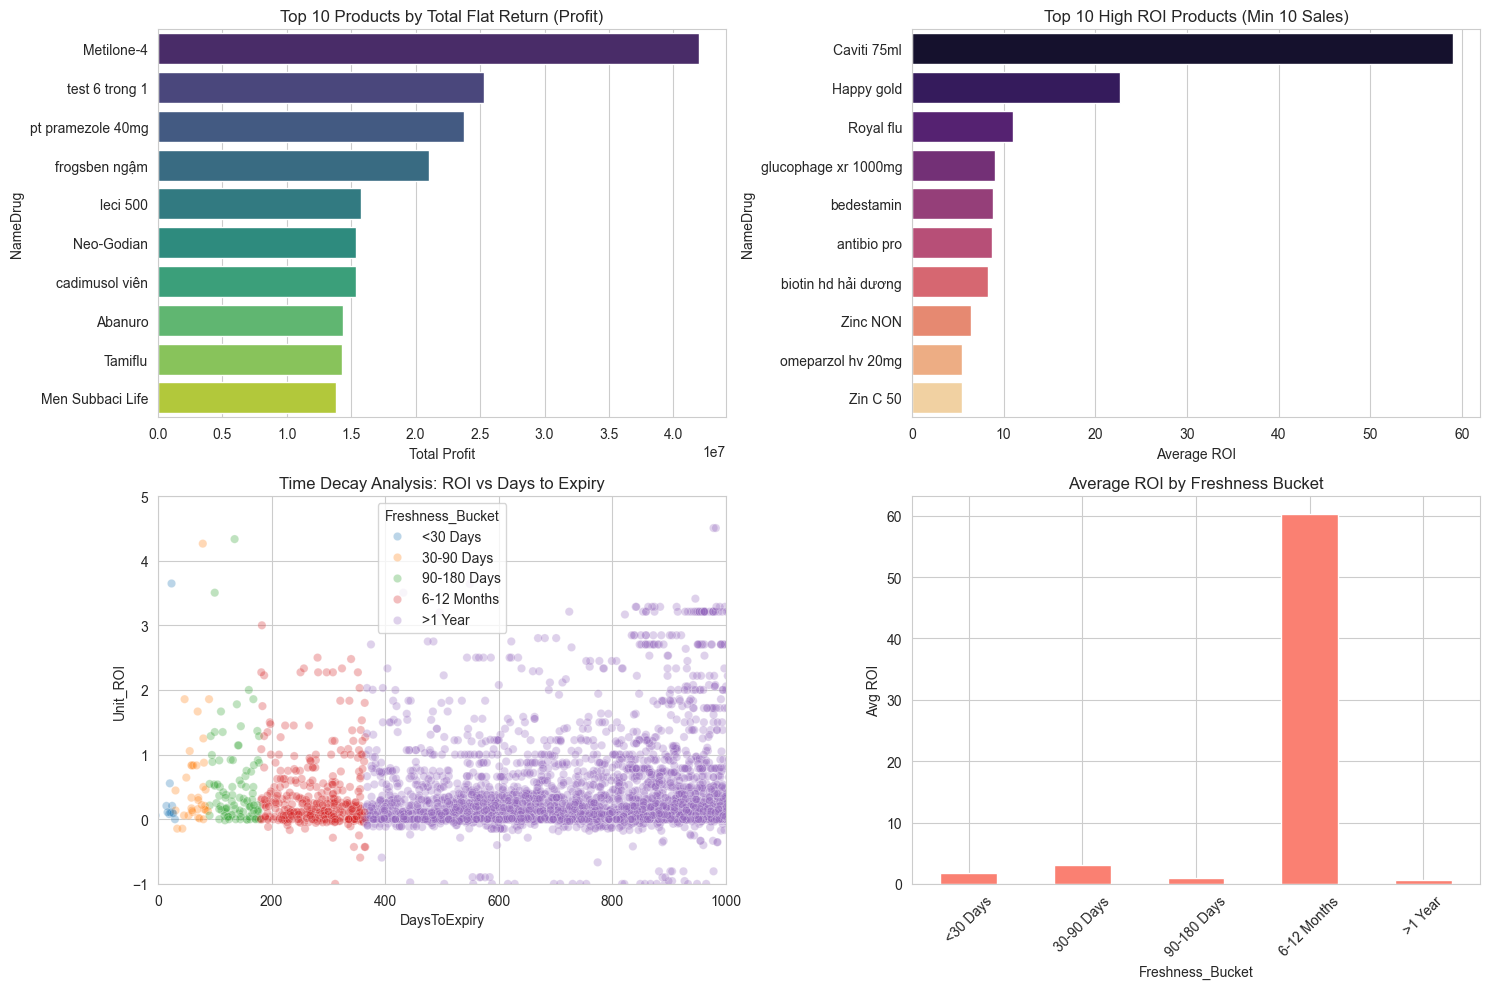

In [20]:
# Visualizations: Product Returns & Decay

plt.figure(figsize=(15, 10))

# 1. Top 10 Products by Total Flat Return (Profit)
plt.subplot(2, 2, 1)
top_profit = df_merged.groupby('NameDrug')['Flat_Return'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_profit.values, y=top_profit.index, hue=top_profit.index, palette='viridis', legend=False)
plt.title('Top 10 Products by Total Flat Return (Profit)')
plt.xlabel('Total Profit')

# 2. Top 10 Products by Avg ROI (min 10 sales)
plt.subplot(2, 2, 2)
roi_stats = df_merged.groupby('NameDrug').agg({'Unit_ROI': 'mean', 'Quantity': 'count'})
top_roi = roi_stats[roi_stats['Quantity'] > 10].sort_values('Unit_ROI', ascending=False).head(10)
sns.barplot(x=top_roi['Unit_ROI'].values, y=top_roi.index, hue=top_roi.index, palette='magma', legend=False)
plt.title('Top 10 High ROI Products (Min 10 Sales)')
plt.xlabel('Average ROI')

# 3. ROI vs. Days to Expiry (Time Decay Scatter)
plt.subplot(2, 2, 3)
# Sample for performance if too large
plot_data = df_decay.sample(min(5000, len(df_decay))) if len(df_decay) > 5000 else df_decay
sns.scatterplot(data=plot_data, x='DaysToExpiry', y='Unit_ROI', alpha=0.3, hue='Freshness_Bucket')
plt.title('Time Decay Analysis: ROI vs Days to Expiry')
plt.xlim(0, 1000) # Focus on near term
plt.ylim(-1, 5)   # Focus on reasonable ROI range

# 4. Average Discount by Freshness (Implied Decay)
plt.subplot(2, 2, 4)
avg_roi_decay = df_decay.groupby('Freshness_Bucket', observed=True)['Unit_ROI'].mean()
avg_roi_decay.plot(kind='bar', color='salmon')
plt.title('Average ROI by Freshness Bucket')
plt.ylabel('Avg ROI')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. Inventory Optimization (ABC/XYZ Analysis)
Classifying products based on value (ABC) and demand variability (XYZ) to recommend inventory strategies.

In [21]:
# Adapted from inventory_analysis.py

def perform_abc_analysis(df_input):
    print("Performing ABC Analysis...")
    # FIX: Ensure numeric columns
    df_input = df_input.copy()
    df_input['Quantity'] = pd.to_numeric(df_input['Quantity'], errors='coerce').fillna(0)
    df_input['Amount'] = pd.to_numeric(df_input['Amount'], errors='coerce').fillna(0)
    # Aggregate sales by medicine
    # Using 'NameDrug' and 'Amount' (Revenue)
    medicine_stats = df_input.groupby('NameDrug').agg({
        'Amount': 'sum',
        'Quantity': 'sum',
        'NoteDate': 'count' # Transaction count
    }).rename(columns={'NoteDate': 'Transaction_Count', 'Amount': 'Total_Amount'})
    
    # Sort by value (Total Amount) descending
    medicine_stats = medicine_stats.sort_values('Total_Amount', ascending=False)
    
    # Calculate cumulative percentage
    total_revenue = medicine_stats['Total_Amount'].sum()
    medicine_stats['Cumulative_Revenue'] = medicine_stats['Total_Amount'].cumsum()
    medicine_stats['Revenue_Share'] = medicine_stats['Cumulative_Revenue'] / total_revenue
    
    # Assign ABC Class
    def get_abc_class(x):
        if x <= 0.80:
            return 'A' # Top 80% Revenue
        elif x <= 0.95:
            return 'B' # Next 15%
        else:
            return 'C' # Bottom 5%
            
    medicine_stats['ABC_Class'] = medicine_stats['Revenue_Share'].apply(get_abc_class)
    return medicine_stats

def perform_xyz_analysis(df_input, medicine_stats):
    print("Performing XYZ Analysis (Demand Variability)...")

    # FIX: Ensure numeric columns
    df_input = df_input.copy()
    df_input['Quantity'] = pd.to_numeric(df_input['Quantity'], errors='coerce').fillna(0)
    
    # Calculate daily demand
    daily_demand = df_input.groupby(['NameDrug', pd.Grouper(key='NoteDate', freq='D')])['Quantity'].sum().reset_index()
    
    # Fill days with 0 sales for robust variability calculation
    min_date = df_input['NoteDate'].min()
    max_date = df_input['NoteDate'].max()
    all_dates = pd.date_range(min_date, max_date)
    
    cv_data = []
    
    # Optimization: Iterate only over processed medicines
    for medicine in medicine_stats.index:
        # Filter for specific medicine and select Quantity column (Series)
        med_daily = daily_demand[daily_demand['NameDrug'] == medicine].set_index('NoteDate')['Quantity']
        
        # Reindex to include all days with 0 sales
        med_daily = med_daily.reindex(all_dates, fill_value=0)
        
        mean_demand = med_daily.mean()
        std_demand = med_daily.std()
        
        if mean_demand > 0:
            cv = std_demand / mean_demand
        else:
            cv = 0
            
        cv_data.append({'NameDrug': medicine, 'Daily_Mean': mean_demand, 'Daily_Std': std_demand, 'CV': cv})
        
    cv_df = pd.DataFrame(cv_data).set_index('NameDrug')
    
    # Combine with stats
    medicine_stats = medicine_stats.join(cv_df)
    
    # Assign XYZ Class
    def get_xyz_class(x):
        if x < 0.5: # Adjusted threshold for daily data (0.2 might be too strict for retail daily)
            return 'X' # Predictable
        elif x < 1.0:
            return 'Y' # Moderate
        else:
            return 'Z' # Erratic
            
    medicine_stats['XYZ_Class'] = medicine_stats['CV'].apply(get_xyz_class)
    return medicine_stats

Performing ABC Analysis...
Performing XYZ Analysis (Demand Variability)...

Inventory Matrix (Count of Products):


XYZ_Class,Z
ABC_Class,
A,1228
B,1504
C,2294


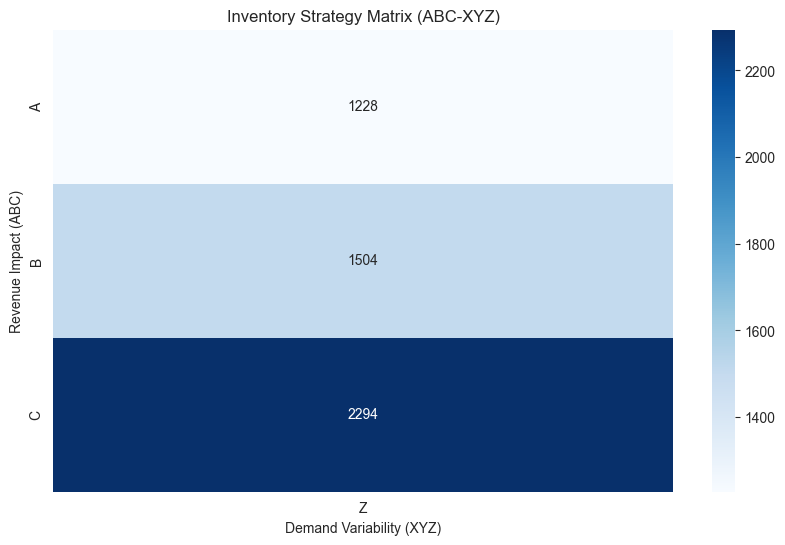

In [22]:
# Run Analysis
inventory_stats = perform_abc_analysis(df_sales)
inventory_stats = perform_xyz_analysis(df_sales, inventory_stats)

# Generate Recommendations
def generate_recommendations(row):
    abc = row['ABC_Class']
    xyz = row['XYZ_Class']
    combo = abc + xyz
    
    if combo == 'AX':
        return "High Value, Steady. Strategy: JIT Replenishment."
    elif combo == 'AZ':
        return "High Value, Erratic. Strategy: High Safety Stock."
    elif combo == 'CX':
        return "Low Value, Steady. Strategy: Bulk Buy."
    elif combo == 'CZ':
        return "Low Value, Erratic. Strategy: Review for De-listing."
    else:
        return "Standard Management."

inventory_stats['Recommendation'] = inventory_stats.apply(generate_recommendations, axis=1)

print("\nInventory Matrix (Count of Products):")
matrix = inventory_stats.groupby(['ABC_Class', 'XYZ_Class'], observed=False).size().unstack(fill_value=0)
display(matrix)

# Visualizing the Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Inventory Strategy Matrix (ABC-XYZ)')
plt.xlabel('Demand Variability (XYZ)')
plt.ylabel('Revenue Impact (ABC)')
plt.show()

## 8. Inventory Optimization (ABC/XYZ Analysis)

Classifying products based on Revenue Share (ABC) and Demand Variability (XYZ) to optimize inventory levels.

In [23]:
import pandas as pd
import numpy as np

def perform_abc_analysis(df_input):
    print("Performing ABC Analysis...")
    medicine_stats = df_input.groupby('NameDrug').agg({
        'Amount': 'sum',
        'Quantity': 'sum',
        'NoteDate': 'count'
    }).rename(columns={'NoteDate': 'Transaction_Count', 'Amount': 'Total_Amount'})
    
    medicine_stats = medicine_stats.sort_values('Total_Amount', ascending=False)
    
    total_revenue = medicine_stats['Total_Amount'].sum()
    medicine_stats['Cumulative_Revenue'] = medicine_stats['Total_Amount'].cumsum()
    medicine_stats['Revenue_Share'] = medicine_stats['Cumulative_Revenue'] / total_revenue
    
    def get_abc_class(x):
        if x <= 0.80: return 'A'
        elif x <= 0.95: return 'B'
        else: return 'C'
            
    medicine_stats['ABC_Class'] = medicine_stats['Revenue_Share'].apply(get_abc_class)
    return medicine_stats

def perform_xyz_analysis(df_input, medicine_stats):
    print("Performing XYZ Analysis (Demand Variability)...")
    
    daily_demand = df_input.groupby(['NameDrug', pd.Grouper(key='NoteDate', freq='D')])['Quantity'].sum().reset_index()
    
    min_date = df_input['NoteDate'].min()
    max_date = df_input['NoteDate'].max()
    all_dates = pd.date_range(min_date, max_date)
    
    cv_data = []
    
    for medicine in medicine_stats.index:
        # CORRECT FIX: Select Quantity column (Series) before reindexing
        med_daily = daily_demand[daily_demand['NameDrug'] == medicine].set_index('NoteDate')['Quantity']
        
        # Reindex to include all days with 0 sales
        med_daily = med_daily.reindex(all_dates, fill_value=0)
        
        mean_demand = med_daily.mean()
        std_demand = med_daily.std()
        
        if mean_demand > 0:
            cv = std_demand / mean_demand
        else:
            cv = 0
            
        cv_data.append({'NameDrug': medicine, 'Daily_Mean': mean_demand, 'Daily_Std': std_demand, 'CV': cv})
        
    cv_df = pd.DataFrame(cv_data).set_index('NameDrug')
    medicine_stats = medicine_stats.join(cv_df)
    
    def get_xyz_class(x):
        if x < 0.5: return 'X'
        elif x < 1.0: return 'Y'
        else: return 'Z'
            
    medicine_stats['XYZ_Class'] = medicine_stats['CV'].apply(get_xyz_class)
    return medicine_stats


Starting Inventory Optimization Analysis...
Performing ABC Analysis...
Performing XYZ Analysis (Demand Variability)...

Optimization Summary:
                  ABC_Class XYZ_Class  Transaction_Count  Total_Amount
NameDrug                                                              
Ketosteril 600mg          A         Z                 75   136149400.0
Augmentin 1g              A         Z                498   113052612.0
Cerebrolysin 10ml         A         Z                106   112759000.0
avastranso                A         Z                101   105943980.0
Tamiflu                   A         Z                267   104996400.0

Succesfully saved report to: Inventory_Optimization_Report.xlsx


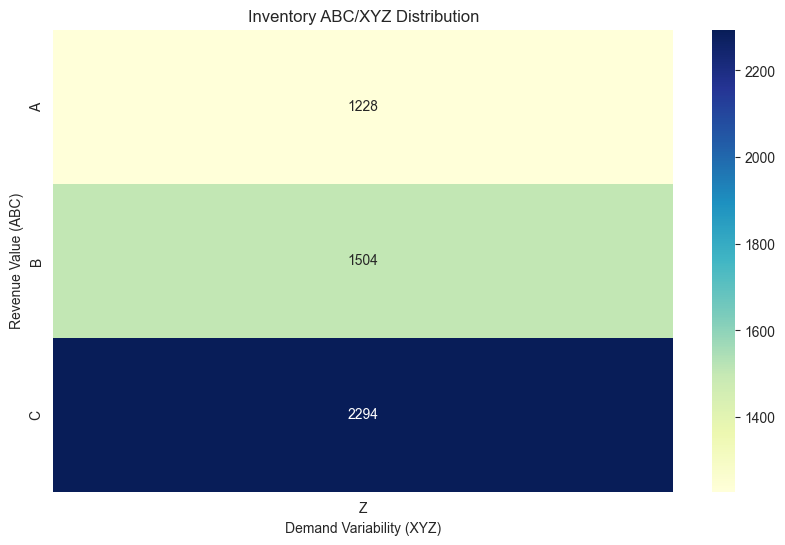

In [24]:

# Execute Inventory Analysis
print("Starting Inventory Optimization Analysis...")

# 1. ABC Analysis
df_abc = perform_abc_analysis(df_sales)

# 2. XYZ Analysis
# Note: perform_xyz_analysis requires 'medicine_stats' (which is df_abc) and 'df_input' (df_sales)
df_combined = perform_xyz_analysis(df_sales, df_abc)

# 3. Aggregate Final Report
print("\nOptimization Summary:")
print(df_combined[['ABC_Class', 'XYZ_Class', 'Transaction_Count', 'Total_Amount']].head())

# 4. Export
output_file = 'Inventory_Optimization_Report.xlsx'
try:
    df_combined.to_excel(output_file)
    print(f"\nSuccesfully saved report to: {output_file}")
except Exception as e:
    print(f"\nError saving report: {e}")

# 5. Visual Distribution
plt.figure(figsize=(10, 6))
# Pivot for heatmap
pivot_table = pd.crosstab(df_combined['ABC_Class'], df_combined['XYZ_Class'])
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Inventory ABC/XYZ Distribution')
plt.xlabel('Demand Variability (XYZ)')
plt.ylabel('Revenue Value (ABC)')
plt.show()
